# Centralized Baseline

> Implementation of the centralized models that run on the server side, establishing the performance ceiling for the federated experiments.

---

## Motivation

For health-related applications, high interpretability models are generally preferred, but in a FL setup those models do not make much sense, as we work with iterations and gradient descent, which highly suits NN models. This project is not about that, but rather the FL technicality. For the centralized baseline, two models have been trained: **XGBoost** and a **Neural Network (MLP)**.

---

## Dataset

The **Diabetes 130-US Hospitals for Years 1999–2008** dataset was chosen for this project, as it can be understood that hospitals cannot share data between themselves — only sharing finalized models — so it makes sense in a realistic federated scenario.

| Property | Details |
|---|---|
| Time span | 1999–2008 |
| Hospitals | 130 US hospitals |
| Samples | ~101,766 patient encounters |
| Task | Predict 30-day hospital readmission |

This dataset is challenging: some data preparation must be done, and state-of-the-art models achieve around **0.667 AUC-ROC**. Its relatively small size also reflects what we encounter in everyday hospital settings, making it a realistic and useful reference.

---

## Results Summary

| Model | AUC-ROC | Notes |
|---|---|---|
| XGBoost | **0.665** | Near SOTA, incompatible with FL |
| MLP | **0.663** | FL-compatible neural baseline |

Both models closely match the published benchmark, confirming they are solid baselines for the federated experiments.

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import joblib
import os

from sklearn.model_selection import  GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, roc_auc_score,
    classification_report
)
from xgboost import XGBClassifier
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Data Preprocessing

Preprocessing starts by replacing all missing values (encoded as `'?'`) with `NaN`. Columns with over 40% missing data are dropped (e.g. `weight`). For the remaining affected columns — `race`, `diag_1`, `diag_2`, `diag_3` — missing values are filled with `'Unknown'`, affecting at most 3% of the dataset.

The **target variable** is binarized:
- `1` — readmitted within 30 days
- `0` — otherwise

This produces an approximate class imbalance of **1:9**, discussed below.

Categorical features are mapped to clinically meaningful groups — ICD-9 diagnosis codes to eight disease categories, admission and discharge fields to broad types — and then **one-hot encoded**, which is why the working dataset has more columns than the original.


In [20]:
COLS_TO_DROP = ['weight', 'max_glu_serum', 'A1Cresult', 
                'medical_specialty', 'payer_code', 
                'encounter_id']

DECEASED_IDS = [11, 19, 20, 21]

ADMISSION_TYPE_MAP = {
    1: 'emergency', 2: 'urgent',   3: 'elective',
    4: 'newborn',   5: 'unknown',  6: 'unknown',
    7: 'emergency', 8: 'unknown'
}

ADMISSION_SOURCE_MAP = {
    1: 'referral', 2: 'referral', 3: 'referral',
    4: 'transfer', 5: 'transfer', 6: 'transfer',
    10: 'transfer', 18: 'transfer', 22: 'transfer', 
    25: 'transfer', 26: 'transfer',
    7: 'emergency',
    11: 'newborn', 12: 'newborn', 13: 'newborn',
    14: 'newborn', 23: 'newborn', 24: 'newborn',
    9: 'unknown', 15: 'unknown', 17: 'unknown',
    20: 'unknown', 21: 'unknown',
    8: 'other', 19: 'other',
}

AGE_MAP = {
    '[0-10)': 0,  '[10-20)': 1, '[20-30)': 2, '[30-40)': 3,
    '[40-50)': 4, '[50-60)': 5, '[60-70)': 6, '[70-80)': 7,
    '[80-90)': 8, '[90-100)': 9
}

MED_COLS = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

MED_MAP = {'No': 0, 'Steady': 1, 'Up': 2, 'Down': 3}



In [21]:
def load_data(path: str) -> pd.DataFrame:
    """Load raw CSV and replace ? with NaN."""
    df = pd.read_csv(path)
    df.replace('?', np.nan, inplace=True)
    return df


def drop_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Drop high-missing and ID columns."""
    return df.drop(columns=COLS_TO_DROP)


def remove_deceased(df: pd.DataFrame) -> pd.DataFrame:
    """Remove patients who died — they cannot be readmitted."""
    return df[~df['discharge_disposition_id'].isin(DECEASED_IDS)].copy()


def create_target(df: pd.DataFrame) -> pd.DataFrame:
    """Create binary target: 1 if readmitted within 30 days, 0 otherwise."""
    df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)
    df.drop(columns=['readmitted'], inplace=True)
    return df


def group_discharge(x):
    if x in [11, 19, 20, 21]:          return 'expired'
    elif x in [1, 6, 8]:               return 'home'
    elif x in [2, 3, 4, 5, 10, 15, 16,
            22, 23, 24, 27, 28,
            29, 30]:                return 'transfer'
    elif x in [13, 14]:                return 'hospice'
    elif x == 7:                       return 'ama'
    elif x in [9, 12]:                 return 'inpatient'  # still admitted
    elif x in [18, 25, 26]:            return 'unknown'
    else:                              return 'other'


def group_icd9(code):
    try:
        code = str(code)
        if code.startswith('V') or code.startswith('E'): return 'other'
        c = float(code)
        if   390 <= c <= 459 or c == 785: return 'circulatory'
        elif 460 <= c <= 519 or c == 786: return 'respiratory'
        elif 520 <= c <= 579 or c == 787: return 'digestive'
        elif 250 <= c <= 250.99:          return 'diabetes'
        elif 800 <= c <= 999:             return 'injury'
        elif 710 <= c <= 739:             return 'musculoskeletal'
        elif 580 <= c <= 629 or c == 788: return 'genitourinary'
        elif 140 <= c <= 239:             return 'neoplasms'
        else:                             return 'other'
    except:
        return 'other'


def encode_features(df: pd.DataFrame) -> pd.DataFrame:
    """Apply all feature encoding and grouping."""
    # Ordinal
    df['age'] = df['age'].map(AGE_MAP)

    # Clinical groupings
    df['admission_type_id'] = df['admission_type_id'].map(ADMISSION_TYPE_MAP).fillna('unknown')
    df['admission_source_id']     = df['admission_source_id'].map(ADMISSION_SOURCE_MAP).fillna('unknown')
    df['discharge_disposition_id'] = df['discharge_disposition_id'].apply(group_discharge)

    # ICD-9 diagnosis codes
    for col in ['diag_1', 'diag_2', 'diag_3']:
        df[col] = df[col].apply(group_icd9)

    # Medication columns
    for col in MED_COLS:
        if col in df.columns:
            df[col] = df[col].map(MED_MAP)

    df['change']      = (df['change'] == 'Ch').astype(int)
    df['diabetesMed'] = (df['diabetesMed'] == 'Yes').astype(int)

    # One-hot encode categoricals
    df = pd.get_dummies(df, columns=[
        'diag_1', 'diag_2', 'diag_3',
        'admission_type_id', 'admission_source_id',
        'discharge_disposition_id', 'race', 'gender'
    ])

    return df


def prepare_data(path: str, verbose: bool = True) -> tuple:
    df = load_data(path)
    df = drop_columns(df)
    df = remove_deceased(df)
    df = create_target(df)

    # Impute instead of dropping
    df['race'] = df['race'].fillna('Unknown')
    for col in ['diag_1', 'diag_2', 'diag_3']:
        df[col] = df[col].fillna('Unknown')  # group_icd9 handles 'Unknown' → 'other'
    
    # Only drop rows that are still genuinely incomplete
    # (numeric columns like num_lab_procedures that can't be imputed safely)
    df.dropna(inplace=True)
    
    df = encode_features(df)

    if verbose:
        print(f"Dataset shape after cleaning: {df.shape}")
        print(f"Class distribution:\n{df['readmitted_binary'].value_counts()}")

    groups = df['patient_nbr'].values
    X = df.drop(columns=['readmitted_binary', 'patient_nbr']).values
    y = df['readmitted_binary'].values

    return X, y, groups

X, y, groups = prepare_data('../diabetes_data/diabetic_data.csv')


Dataset shape after cleaning: (100114, 90)
Class distribution:
readmitted_binary
0    88757
1    11357
Name: count, dtype: int64


## Train / Validation / Test Split

To prevent **data leakage** — the same patient appearing in both training and test sets — the split is performed at the **patient level**, using `patient_nbr` as the grouping key, which is then dropped.

| Split | Size |
|---|---|
| Train | 68% |
| Validation | 12% |
| Test | 20% |

In [22]:
# Patient-level train/test split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_temp, X_test = X[train_idx], X[test_idx]
y_temp, y_test = y[train_idx], y[test_idx]
groups_temp = groups[train_idx]

# Patient-level train/val split
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx2, val_idx = next(gss2.split(X_temp, y_temp, groups=groups_temp))

X_train, X_val = X_temp[train_idx2], X_temp[val_idx]
y_train, y_val = y_temp[train_idx2], y_temp[val_idx]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Tensors for val/test (no SMOTE on these)
X_val_t  = torch.tensor(X_val_scaled,  dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_val_t  = torch.tensor(y_val,  dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# Train DataLoader (no SMOTE)
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=1024, shuffle=True)

Train: (67952, 88), Val: (12087, 88), Test: (20075, 88)


## Class Imbalance

The dataset has a class imbalance of approximately **9:1**. Instead of synthetic oversampling (e.g. SMOTE), which can produce unrealistic samples for one-hot encoded medical data, **class-weighted cross-entropy loss** is used. Weights are computed inversely proportional to class frequencies, penalizing the model more heavily for missed readmissions.


Class Distribution:
0    60302
1     7650
Name: count, dtype: int64

Class Proportions:
0    0.887421
1    0.112579
Name: proportion, dtype: float64


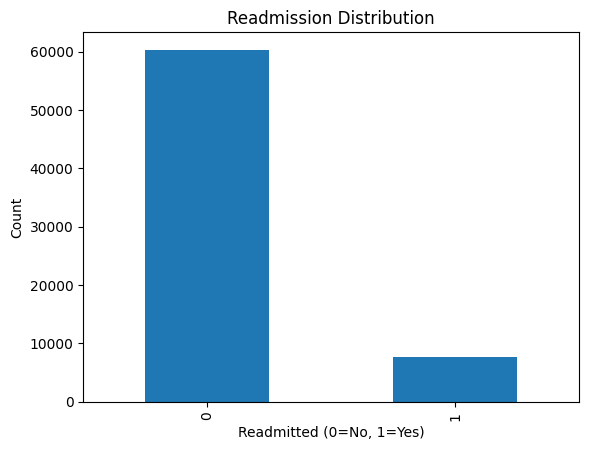

In [23]:
# Check class distribution
print("Class Distribution:")
print(pd.Series(y_train).value_counts())
print("\nClass Proportions:")
print(pd.Series(y_train).value_counts(normalize=True))

# Visualize

pd.Series(y_train).value_counts().plot(kind='bar', title='Readmission Distribution')
plt.xlabel('Readmitted (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

## XGBoost

A gradient boosted tree ensemble used as the **performance ceiling**. XGBoost natively handles class imbalance via `scale_pos_weight`, set to the negative-to-positive class ratio. Hyperparameters — including `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree` and `min_child_weight` — are tuned using **Optuna** with 50 trials and TPE sampling, optimizing validation AUC-ROC. Early stopping is applied to prevent overfitting. Note that XGBoost receives **raw unscaled features**, as tree-based models are invariant to feature scaling. 5-fold group cross-validation is used to confirm stability across patient groups.

> Important: XGBoost is incompatible with FL frameworks — its sequential tree-building process cannot be meaningfully aggregated across clients the way neural network gradients can. It serves purely as an upper-bound reference.


In [24]:
# ── XGBoost Hyperparameter Optimization ──────────────────────
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

def xgb_objective(trial):
    params = {
        'n_estimators':          trial.suggest_int('n_estimators', 100, 500),
        'max_depth':             trial.suggest_int('max_depth', 3, 10),
        'learning_rate':         trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':             trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':      trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':      trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight':      (y_train == 0).sum() / (y_train == 1).sum(),
        'eval_metric':           'auc',
        'early_stopping_rounds': 25,
        'random_state':          42,
        'device':                'cuda'
    }
    m = XGBClassifier(**params)
    m.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    proba = m.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, proba)

print("Optimizing XGBoost...")
xgb_study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

print(f"\nBest XGBoost AUC: {xgb_study.best_value:.3f}")
print(f"Best params: {xgb_study.best_params}")

# ── XGBoost Retrain with best params ─────────────────────────
best_xgb_params = xgb_study.best_params
best_xgb_params.update({
    'scale_pos_weight':      (y_train == 0).sum() / (y_train == 1).sum(),
    'eval_metric':           'auc',
    'early_stopping_rounds': 25,
    'random_state':          42,
    'device':                'cuda'
})

model_xgb = XGBClassifier(**best_xgb_params)
model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# ── XGBoost Evaluate ─────────────────────────────────────────
y_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb  = model_xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))
print(f"XGBoost AUC-ROC: {roc_auc_score(y_test, y_proba_xgb):.3f}")

Optimizing XGBoost...


Best trial: 38. Best value: 0.670529: 100%|██████████| 50/50 [01:09<00:00,  1.39s/it]



Best XGBoost AUC: 0.671
Best params: {'n_estimators': 277, 'max_depth': 4, 'learning_rate': 0.12330640137732905, 'subsample': 0.9723847789559605, 'colsample_bytree': 0.9231408186888364, 'min_child_weight': 1}
[0]	validation_0-auc:0.64975
[50]	validation_0-auc:0.66899
[93]	validation_0-auc:0.66912
              precision    recall  f1-score   support

           0       0.92      0.65      0.76     17770
           1       0.18      0.58      0.27      2305

    accuracy                           0.64     20075
   macro avg       0.55      0.62      0.52     20075
weighted avg       0.84      0.64      0.71     20075

XGBoost AUC-ROC: 0.657


In [25]:
# ── XGBoost Retrain ───────────────────────────────────────────
best_xgb_params = xgb_study.best_params
best_xgb_params.update({
    'scale_pos_weight': (y_train == 0).sum() / (y_train == 1).sum(),
    'eval_metric':      'auc',
    'early_stopping_rounds': 25,
    'random_state':     42,
    'device':           'cuda'
})

model_xgb = XGBClassifier(**best_xgb_params)
model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

y_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb  = model_xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))
print(f"XGBoost AUC-ROC: {roc_auc_score(y_test, y_proba_xgb):.3f}")

[0]	validation_0-auc:0.64975
[50]	validation_0-auc:0.66899
[93]	validation_0-auc:0.66912
              precision    recall  f1-score   support

           0       0.92      0.65      0.76     17770
           1       0.18      0.58      0.27      2305

    accuracy                           0.64     20075
   macro avg       0.55      0.62      0.52     20075
weighted avg       0.84      0.64      0.71     20075

XGBoost AUC-ROC: 0.657


In [26]:
df_temp = pd.read_csv('../diabetes_data/diabetic_data.csv')
df_temp.replace('?', np.nan, inplace=True)
df_temp = drop_columns(df_temp)
df_temp = remove_deceased(df_temp)
df_temp = create_target(df_temp)
df_temp['race'] = df_temp['race'].fillna('Unknown') 
df_temp.dropna(inplace=True)
df_temp = encode_features(df_temp)
feature_names_list = df_temp.drop(columns=['readmitted_binary', 'patient_nbr']).columns.tolist()

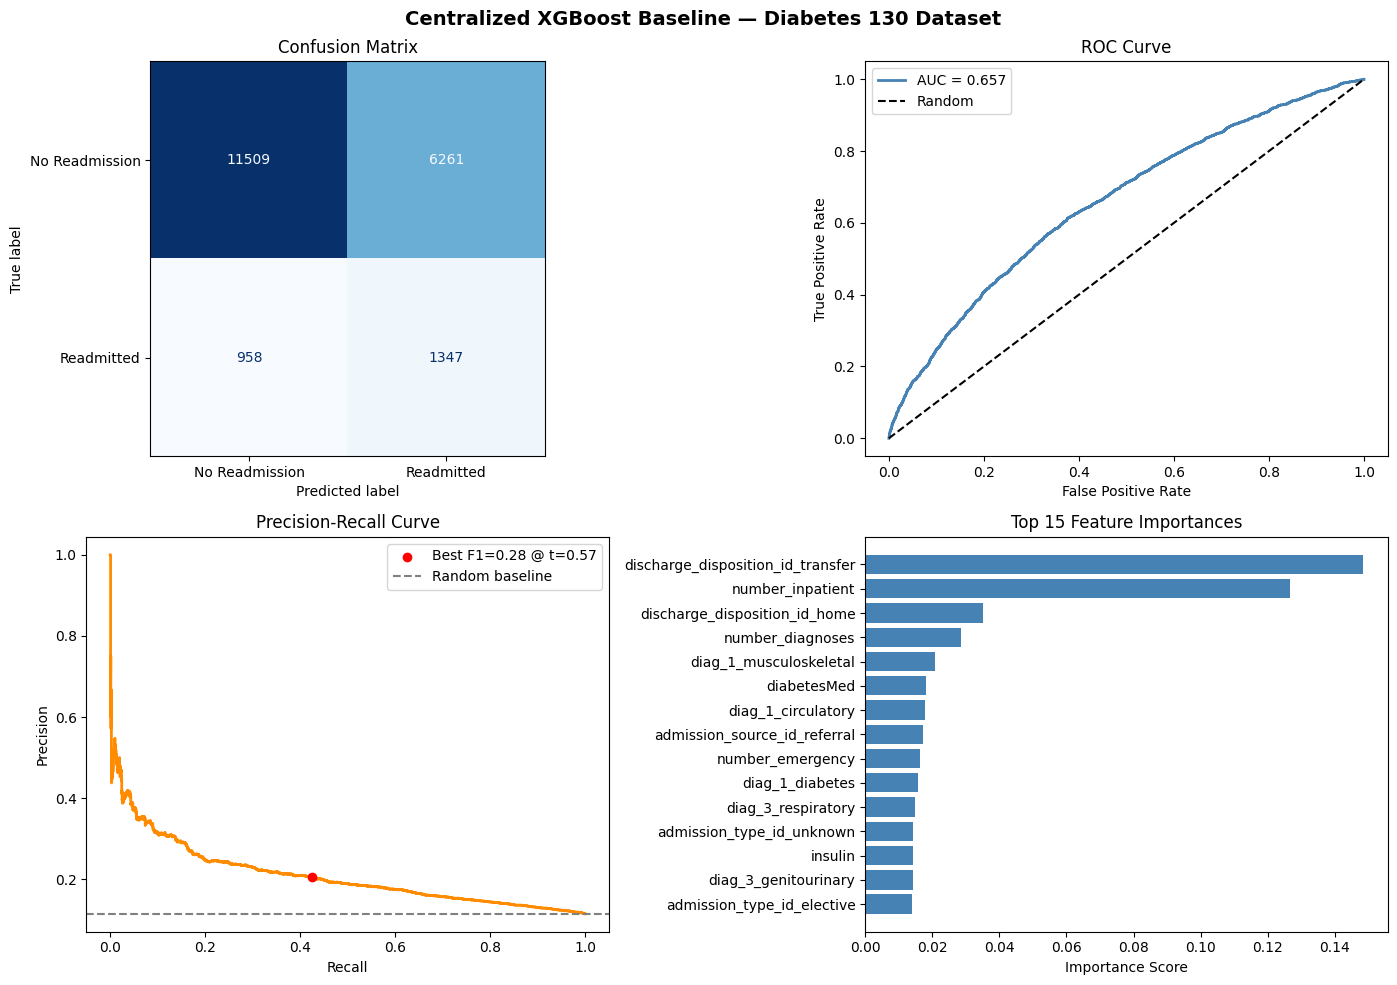

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Centralized XGBoost Baseline — Diabetes 130 Dataset', fontsize=14, fontweight='bold')

# 1. Confusion Matrix
ax1 = axes[0, 0]
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Readmission', 'Readmitted'])
disp.plot(cmap='Blues', ax=ax1, colorbar=False)
ax1.set_title('Confusion Matrix')

# 2. ROC Curve
ax2 = axes[0, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)
auc = roc_auc_score(y_test, y_proba_xgb)
ax2.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.3f}')
ax2.plot([0, 1], [0, 1], 'k--', label='Random')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend()

# 3. Precision-Recall Curve
ax3 = axes[1, 0]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_xgb)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
ax3.plot(recall, precision, color='darkorange', lw=2)
ax3.scatter(recall[best_idx], precision[best_idx], color='red', zorder=5,
            label=f'Best F1={f1_scores[best_idx]:.2f} @ t={thresholds[best_idx]:.2f}')
ax3.axhline(y_test.mean(), color='gray', linestyle='--', label='Random baseline')
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Curve')
ax3.legend()

# 4. Top 15 Feature Importances
ax4 = axes[1, 1]
importances = model_xgb.feature_importances_
top_idx = np.argsort(importances)[-15:]
feature_names = [feature_names_list[i] for i in top_idx]
ax4.barh(feature_names, importances[top_idx], color='steelblue')
ax4.set_title('Top 15 Feature Importances')
ax4.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('xgboost_baseline.png', dpi=150, bbox_inches='tight')
plt.show()


## MLP

A three-layer perceptron serving as the **federated-compatible neural baseline**, with a funnel architecture (`hidden_dim → hidden_dim/2 → hidden_dim/4 → 2`). Each hidden layer is followed by batch normalisation and dropout for regularisation. Hyperparameters — including `hidden_dim`, `dropout`, `learning_rate` and `batch_size` — are tuned using **Optuna** with 30 trials, TPE sampling and median pruning to discard unpromising trials early. The final model is trained with the Adam optimiser for up to 100 epochs, retaining the best checkpoint by validation loss. Features are standardised with `StandardScaler` fitted only on the training set. 5-fold group cross-validation confirms generalisation across patient groups.

> ⚠️ While NNs are not the preferred choice for medical data in practice — where interpretability is critical for clinical trust — the focus of this project is the FL-KD framework rather than clinical deployment. SHAP values are applied post-hoc to provide feature-level explanations.

In [28]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, output_dim=2, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),          # ✅ uses parameter
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),          # ✅ uses parameter
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.ReLU(),
            nn.Linear(hidden_dim // 4, output_dim)
        )
    def forward(self, x):
        return self.net(x)

In [29]:
# ── MLP Hyperparameter Optimization ──────────────────────────
def mlp_objective(trial):
    hidden_dim = trial.suggest_categorical('hidden_dim', [128, 256, 512])
    dropout    = trial.suggest_float('dropout', 0.1, 0.5)
    lr         = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [512, 1024, 2048])

    X_tr_t = torch.tensor(X_train_scaled, dtype=torch.float32)
    X_va_t = torch.tensor(X_val_scaled,   dtype=torch.float32)
    y_tr_t = torch.tensor(y_train, dtype=torch.long)
    y_va_t = torch.tensor(y_val,   dtype=torch.long)

    loader = DataLoader(
        TensorDataset(X_tr_t, y_tr_t),
        batch_size=batch_size, shuffle=True
    )

    cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    criterion_opt = nn.CrossEntropyLoss(
        weight=torch.tensor(cw, dtype=torch.float32).to(device)
    )

    class MLPTrial(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(X_train_scaled.shape[1], hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.BatchNorm1d(hidden_dim // 2),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim // 2, hidden_dim // 4),
                nn.ReLU(),
                nn.Linear(hidden_dim // 4, 2)
            )
        def forward(self, x):
            return self.net(x)

    model_t = MLPTrial().to(device)
    optimizer_t = torch.optim.Adam(model_t.parameters(), lr=lr)

    best_auc = 0.0
    for epoch in range(50):
        model_t.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer_t.zero_grad()
            criterion_opt(model_t(xb), yb).backward()
            optimizer_t.step()

        model_t.eval()
        with torch.no_grad():
            proba = torch.softmax(
                model_t(X_va_t.to(device)), dim=1
            )[:, 1].cpu().numpy()
        auc = roc_auc_score(y_val, proba)
        best_auc = max(best_auc, auc)

        trial.report(auc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_auc

print("Optimizing MLP...")
mlp_study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
)
mlp_study.optimize(mlp_objective, n_trials=30, show_progress_bar=True)

print(f"\nBest MLP AUC: {mlp_study.best_value:.3f}")
print(f"Best params: {mlp_study.best_params}")

Optimizing MLP...


Best trial: 21. Best value: 0.665428: 100%|██████████| 30/30 [45:56<00:00, 91.90s/it]  


Best MLP AUC: 0.665
Best params: {'hidden_dim': 256, 'dropout': 0.390197825544754, 'lr': 0.0008004197114809337, 'batch_size': 512}


In [30]:
# ── MLP Retrain ───────────────────────────────────────────────
best_p = mlp_study.best_params
input_dim = X_train_scaled.shape[1]

model = MLP(
    input_dim=input_dim,
    hidden_dim=best_p['hidden_dim'],
    output_dim=2,
    dropout=best_p['dropout']
).to(device)

optimizer  = torch.optim.Adam(model.parameters(), lr=best_p['lr'])
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(cw, dtype=torch.float32).to(device)
)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=best_p['batch_size'], shuffle=True
)

best_val_loss = float('inf')
best_state    = None

for epoch in range(100):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        criterion(model(xb), yb).backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t.to(device))
        val_loss   = criterion(val_logits, y_val_t.to(device))
        val_preds  = val_logits.argmax(dim=1).cpu()
        val_acc    = (val_preds == y_val_t).float().mean()

    scheduler.step(val_loss.item())

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.3f}")

model.load_state_dict(best_state)
model.eval()
with torch.no_grad():
    logits     = model(X_test_t.to(device))
    y_proba_mlp = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
    preds_mlp   = logits.argmax(dim=1).cpu().numpy()

print(classification_report(y_test, preds_mlp))
print(f"MLP AUC-ROC: {roc_auc_score(y_test, y_proba_mlp):.3f}")

Epoch 0 | Val Loss: 0.6603 | Val Acc: 0.637
Epoch 10 | Val Loss: 0.6579 | Val Acc: 0.605
Epoch 20 | Val Loss: 0.6654 | Val Acc: 0.628
Epoch 30 | Val Loss: 0.6678 | Val Acc: 0.629
Epoch 40 | Val Loss: 0.6724 | Val Acc: 0.632
Epoch 50 | Val Loss: 0.6718 | Val Acc: 0.626
Epoch 60 | Val Loss: 0.6718 | Val Acc: 0.630
Epoch 70 | Val Loss: 0.6734 | Val Acc: 0.629
Epoch 80 | Val Loss: 0.6732 | Val Acc: 0.633
Epoch 90 | Val Loss: 0.6721 | Val Acc: 0.626
              precision    recall  f1-score   support

           0       0.93      0.59      0.72     17770
           1       0.17      0.63      0.26      2305

    accuracy                           0.59     20075
   macro avg       0.55      0.61      0.49     20075
weighted avg       0.84      0.59      0.67     20075

MLP AUC-ROC: 0.658


In [31]:
# Eval
model.eval()
with torch.no_grad():
    preds = model(X_test_t.to(device)).argmax(dim=1).cpu().numpy()


print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.93      0.59      0.72     17770
           1       0.17      0.63      0.26      2305

    accuracy                           0.59     20075
   macro avg       0.55      0.61      0.49     20075
weighted avg       0.84      0.59      0.67     20075



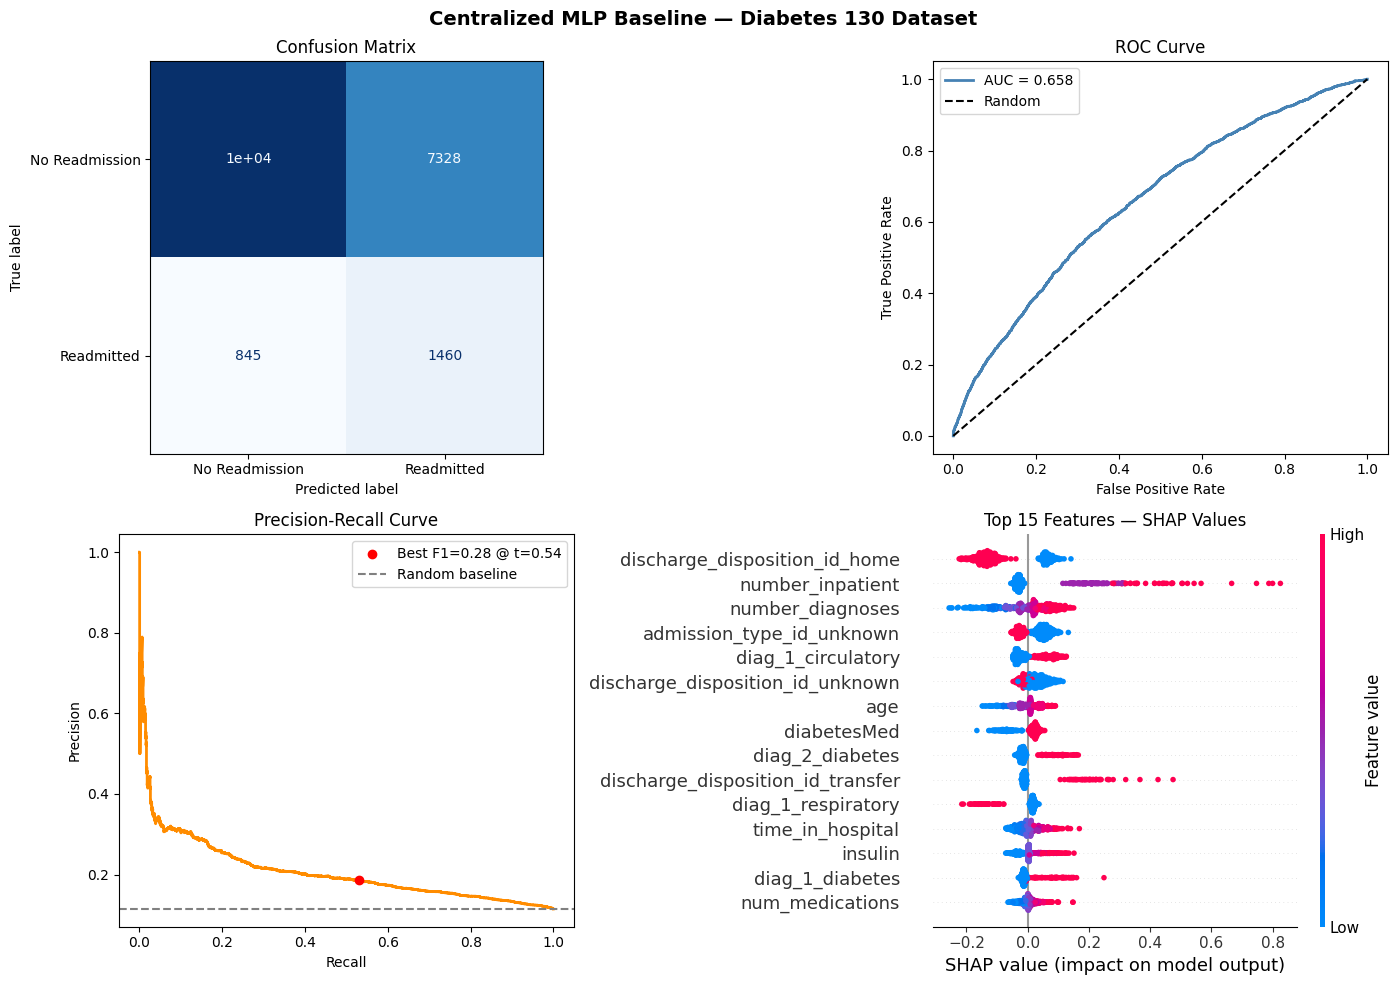

In [32]:
import shap
# Compute predictions and probabilities
model.eval()
with torch.no_grad():
    logits = model(X_test_t.to(device))
    y_proba_mlp = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
    preds_mlp = logits.argmax(dim=1).cpu().numpy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Centralized MLP Baseline — Diabetes 130 Dataset', fontsize=14, fontweight='bold')

# 1. Confusion Matrix
ax1 = axes[0, 0]
cm = confusion_matrix(y_test, preds_mlp)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Readmission', 'Readmitted'])
disp.plot(cmap='Blues', ax=ax1, colorbar=False)
ax1.set_title('Confusion Matrix')

# 2. ROC Curve
ax2 = axes[0, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba_mlp)
auc = roc_auc_score(y_test, y_proba_mlp)
ax2.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.3f}')
ax2.plot([0, 1], [0, 1], 'k--', label='Random')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend()

# 3. Precision-Recall Curve
ax3 = axes[1, 0]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_mlp)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
ax3.plot(recall, precision, color='darkorange', lw=2)
ax3.scatter(recall[best_idx], precision[best_idx], color='red', zorder=5,
            label=f'Best F1={f1_scores[best_idx]:.2f} @ t={thresholds[best_idx]:.2f}')
ax3.axhline(y_test.mean(), color='gray', linestyle='--', label='Random baseline')
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Curve')
ax3.legend()

# 4. SHAP Summary Plot (replaces feature importances)
ax4 = axes[1, 1]
background = torch.tensor(X_train_scaled[:500], dtype=torch.float32).to(device)
explainer = shap.DeepExplainer(model, background)
X_explain = torch.tensor(X_test_scaled[:500], dtype=torch.float32).to(device)
shap_values = explainer.shap_values(X_explain)

# Plot SHAP into ax4
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_scaled[:500],
    feature_names=feature_names_list,
    max_display=15,
    show=False,    # ✅ don't render immediately
    plot_size=None # ✅ let matplotlib control the size
)
ax4.set_title('Top 15 Features — SHAP Values')

plt.tight_layout()
plt.savefig('mlp_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

## Cross Validation

In [33]:
# ── Cross Validation with best params ────────────────────────
from sklearn.model_selection import GroupKFold

N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)

xgb_aucs = []
mlp_aucs = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups)):
    print(f"\n--- Fold {fold+1}/{N_SPLITS} ---")

    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    # Scale per fold — fit only on train
    scaler_fold = StandardScaler()
    X_tr_scaled = scaler_fold.fit_transform(X_tr)
    X_te_scaled = scaler_fold.transform(X_te)

    # ── XGBoost ──────────────────────────────────────────────
    xgb_fold = XGBClassifier(**best_xgb_params)
    xgb_fold.fit(
        X_tr, y_tr,                        # raw for XGBoost
        eval_set=[(X_te, y_te)],
        verbose=False
    )
    xgb_proba = xgb_fold.predict_proba(X_te)[:, 1]
    xgb_auc = roc_auc_score(y_te, xgb_proba)
    xgb_aucs.append(xgb_auc)
    print(f"XGBoost AUC: {xgb_auc:.3f}")

    # ── MLP ──────────────────────────────────────────────────
    X_tr_t = torch.tensor(X_tr_scaled, dtype=torch.float32)
    X_te_t = torch.tensor(X_te_scaled, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.long)
    y_te_t = torch.tensor(y_te, dtype=torch.long)

    loader_fold = DataLoader(
        TensorDataset(X_tr_t, y_tr_t),
        batch_size=best_p['batch_size'], shuffle=True
    )

    cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
    criterion_fold = nn.CrossEntropyLoss(
        weight=torch.tensor(cw, dtype=torch.float32).to(device)
    )

    model_fold = MLP(
        input_dim=X_tr_scaled.shape[1],
        hidden_dim=best_p['hidden_dim'],
        output_dim=2,
        dropout=best_p['dropout']
    ).to(device)

    optimizer_fold = torch.optim.Adam(model_fold.parameters(), lr=best_p['lr'])
    scheduler_fold = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_fold, patience=5, factor=0.5
    )

    best_val_loss_fold = float('inf')
    best_state_fold    = None

    for epoch in range(100):
        model_fold.train()
        for xb, yb in loader_fold:
            xb, yb = xb.to(device), yb.to(device)
            optimizer_fold.zero_grad()
            criterion_fold(model_fold(xb), yb).backward()
            optimizer_fold.step()

        model_fold.eval()
        with torch.no_grad():
            val_logits = model_fold(X_te_t.to(device))
            val_loss   = criterion_fold(val_logits, y_te_t.to(device))

        scheduler_fold.step(val_loss.item())

        if val_loss.item() < best_val_loss_fold:
            best_val_loss_fold = val_loss.item()
            best_state_fold = {k: v.clone() for k, v in model_fold.state_dict().items()}

    model_fold.load_state_dict(best_state_fold)
    model_fold.eval()
    with torch.no_grad():
        mlp_proba = torch.softmax(
            model_fold(X_te_t.to(device)), dim=1
        )[:, 1].cpu().numpy()

    mlp_auc = roc_auc_score(y_te, mlp_proba)
    mlp_aucs.append(mlp_auc)
    print(f"MLP     AUC: {mlp_auc:.3f}")

# ── Summary ──────────────────────────────────────────────────
print("\n=== Cross-Validation Results ===")
print(f"XGBoost — Mean AUC: {np.mean(xgb_aucs):.3f} ± {np.std(xgb_aucs):.3f}")
print(f"MLP     — Mean AUC: {np.mean(mlp_aucs):.3f} ± {np.std(mlp_aucs):.3f}")


--- Fold 1/5 ---
XGBoost AUC: 0.662
MLP     AUC: 0.660

--- Fold 2/5 ---
XGBoost AUC: 0.673
MLP     AUC: 0.668

--- Fold 3/5 ---
XGBoost AUC: 0.660
MLP     AUC: 0.661

--- Fold 4/5 ---
XGBoost AUC: 0.673
MLP     AUC: 0.672

--- Fold 5/5 ---
XGBoost AUC: 0.661
MLP     AUC: 0.656

=== Cross-Validation Results ===
XGBoost — Mean AUC: 0.666 ± 0.006
MLP     — Mean AUC: 0.663 ± 0.006




## Interpretability vs FL Suitability

A natural question arises when designing models for federated healthcare applications: is there a model that is both **highly interpretable** and **well-suited for FL**?

This is an open research problem, but the current landscape can be summarised as follows:

| Model | Interpretability | FL Suitability |
|---|---|---|
| Logistic Regression | ✅ High | ✅ High |
| Decision Tree | ✅ High | ❌ Poor |
| XGBoost | 🟡 Medium (via SHAP) | ❌ Poor |
| MLP | ❌ Low | ✅ High |
| MLP + SHAP | 🟡 Post-hoc | ✅ High |

**Logistic Regression** is the closest model to satisfying both requirements — it is fully interpretable via its coefficients and trains via gradient descent, making it compatible with FedAvg aggregation. However, it is a weak learner for complex tabular data and unlikely to capture the non-linear relationships present in clinical datasets.

**Tree-based models** such as Decision Trees and XGBoost offer strong interpretability, but are fundamentally incompatible with FL. Their sequential, tree-building nature cannot be meaningfully aggregated across clients the way neural network gradients can.

**Neural networks** are the natural fit for FL but are inherently opaque. The practical solution adopted in recent research is to apply **post-hoc interpretability tools** — such as SHAP (SHapley Additive exPlanations) — on top of a trained FL model. SHAP values can be computed locally at each client without sharing patient data, and provide clinicians with feature-level explanations of individual predictions.

> In this project, SHAP is applied to the centralized MLP baseline as a proof of concept, illustrating which features most strongly drive 30-day readmission predictions. This approach could naturally extend to the federated setting, where local SHAP explanations could be computed per client post-aggregation.


In [34]:
import joblib
import os

os.makedirs('models', exist_ok=True)

# Save MLP
torch.save({
    'model_state_dict': model.state_dict(),
    'input_dim':        input_dim,
    'hidden_dim':       best_p['hidden_dim'],
    'dropout':          best_p['dropout'],
    'output_dim':       2,
    'scaler':           scaler,
    'best_params':      best_p,             
}, 'models/mlp_centralized.pt')

# Save XGBoost
joblib.dump(model_xgb, 'models/xgboost_centralized.joblib')

# Save XGBoost params separately — useful for CV and FL reference
joblib.dump(best_xgb_params, 'models/xgboost_best_params.joblib')

print("Models saved.")

Models saved.
